# 🖥️ SCHISM tutorial

Parcels v4 supports unstructured-grid model output via [uxarray](https://uxarray.readthedocs.io/).
This tutorial walks through advecting particles in real [SCHISM](http://ccrm.vims.edu/schismweb/)
output from a hydrodynamic hindcast of **Lake Ontario**. SCHISM writes its output in the
[scribe-IO](https://schism-dev.github.io/schism/master/getting-started/output.html) format, which
already follows the [UGRID](https://ugrid-conventions.github.io/ugrid-conventions/) conventions for
its horizontal mesh, so `uxarray` can read it directly.

SCHISM output differs from the [FESOM tutorial](./tutorial_fesom.ipynb) in a few ways that this
tutorial highlights:

1. The mesh coordinates are in a **projected coordinate system (meters)**, not longitude/latitude, so
   we build the grid as a *flat* (Cartesian) mesh.
2. Velocities are stored at **mesh nodes** over a vertical column of layers, ordered **bottom → surface**.
3. SCHISM uses a **localized vertical grid (LSC2)**: the number of valid vertical levels varies from
   node to node, and levels below the seabed are stored as `NaN`. We use this to flag particles that
   end up below the local bathymetry and stop advecting them.

If you have not done so already, work through the
[quickstart tutorial](../../getting_started/tutorial_quickstart.md) first to get familiar with
`ParticleSet`, `Kernel`, and `ParticleFile`.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import uxarray as ux
import xarray as xr

import parcels
import parcels.tutorial

/tmp/ipykernel_2975658/2313679893.py:7: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


## Get the SCHISM tutorial dataset

We use three files from a SCHISM Lake Ontario hindcast (6 hourly snapshots), bundled in Parcels' tutorial
data registry:

* `out2d`: the 2D output, slimmed to the **horizontal mesh** (node/face topology) and bathymetry.
* `horizontalVelX`, `horizontalVelY`: the 3D horizontal velocity components, defined at the mesh nodes
  over 32 vertical layers.

As in the [quickstart](../../getting_started/tutorial_quickstart.md), `parcels.tutorial.open_dataset`
downloads the files into a local cache on first use (subsequent calls return the cached copy) and opens
them as `xarray` datasets:

In [2]:
grid_ds = parcels.tutorial.open_dataset("SCHISM_LakeOntario/out2d")
u = parcels.tutorial.open_dataset("SCHISM_LakeOntario/horizontalVelX")["horizontalVelX"]
v = parcels.tutorial.open_dataset("SCHISM_LakeOntario/horizontalVelY")["horizontalVelY"]
grid_ds

<xarray.Dataset> Size: 32MB
Dimensions:                  (one: 1, nSCHISM_hgrid_node: 295484,
                              nSCHISM_hgrid_face: 549476,
                              nMaxSCHISM_hgrid_face_nodes: 4)
Coordinates:
    SCHISM_hgrid_node_x      (nSCHISM_hgrid_node) float64 2MB dask.array<chunksize=(295484,), meta=np.ndarray>
    SCHISM_hgrid_node_y      (nSCHISM_hgrid_node) float64 2MB dask.array<chunksize=(295484,), meta=np.ndarray>
    SCHISM_hgrid_face_x      (nSCHISM_hgrid_face) float64 4MB dask.array<chunksize=(549476,), meta=np.ndarray>
    SCHISM_hgrid_face_y      (nSCHISM_hgrid_face) float64 4MB dask.array<chunksize=(549476,), meta=np.ndarray>
Dimensions without coordinates: one, nSCHISM_hgrid_node, nSCHISM_hgrid_face,
                                nMaxSCHISM_hgrid_face_nodes
Data variables:
    SCHISM_hgrid             (one) |S1 1B dask.array<chunksize=(1,), meta=np.ndarray>
    SCHISM_hgrid_face_nodes  (nSCHISM_hgrid_face, nMaxSCHISM_hgrid_face_nodes) float64 18MB dask.array<chunksize=(274738, 2), meta=np.ndarray>
    depth                    (nSCHISM_hgrid_node) float32 1MB dask.array<chunksize=(295484,), meta=np.ndarray>

## Build the horizontal mesh

SCHISM stores its mesh topology in `out2d_1.nc` following the UGRID conventions: node coordinates
(`SCHISM_hgrid_node_x/y`) and a face–node connectivity table (`SCHISM_hgrid_face_nodes`). Two
SCHISM-specific details need handling before we hand the mesh to Parcels:

* **Triangular cells.** The connectivity table is stored with a width of 4 (so the same format can
  describe quads), but this Lake Ontario mesh is entirely triangular; the 4th column is all fill. We
  keep the first three columns and convert the 1-based indices to 0-based. Parcels' `UxGrid` requires
  purely triangular cells.
* **Projected coordinates.** The coordinates are in meters (`standard_name = projection_x_coordinate`),
  not degrees. `uxarray` currently assumes node coordinates are spherical and wraps longitudes into
  [-180, 180] (see [uxarray #1524](https://github.com/UXARRAY/uxarray/issues/1524)), which would corrupt
  the mesh. We undo that wrap by writing the raw meter coordinates back, and later build the `FieldSet`
  with `mesh="flat"` so Parcels treats the plane as Cartesian.

In [3]:
node_x = grid_ds["SCHISM_hgrid_node_x"].values.astype("float64")
node_y = grid_ds["SCHISM_hgrid_node_y"].values.astype("float64")
face_nodes = (
    grid_ds["SCHISM_hgrid_face_nodes"].values[:, :3].astype("int64") - 1
)  # all-triangular, 0-based

uxgrid = ux.Grid.from_topology(
    node_lon=node_x, node_lat=node_y, face_node_connectivity=face_nodes, fill_value=-1
)
# undo uxarray's [-180, 180] longitude wrap of the projected meters (uxarray #1524)
uxgrid.node_lon.values[:] = node_x
uxgrid.node_lat.values[:] = node_y

print(
    f"n_node={uxgrid.n_node}, n_face={uxgrid.n_face}, n_max_face_nodes={uxgrid.n_max_face_nodes}"
)
print(f"x range: {node_x.min():.0f} .. {node_x.max():.0f} m")

n_node=295484, n_face=549476, n_max_face_nodes=3
x range: 1364569 .. 1722587 m


## Assemble the velocity fields

The two velocity files hold `horizontalVelX` and `horizontalVelY` with dimensions
`(time, node, layer)`. We rename them to `U`/`V` (so Parcels built-in Kernels recognise the velocity components) and
to the Parcels UGRID dimension names (`n_node` for the lateral dimension).

Two vertical details:

* **Layer ordering.** SCHISM stores levels **bottom → surface**, while Parcels expects depth increasing
  downward from the surface, so we reverse the layer axis.
* **Vertical coordinate.** SCHISM's LSC2 vertical grid (*Localized Sigma Coordinates with Shaved
  cells*) varies with horizontal position: each node has its own layer depths, and even its own
  *number* of levels (the true depths are written to a separate `zCoordinates` output, not used here).
  **Parcels does not currently support a vertical grid that varies with lateral position.** `UxGrid`
  takes a single 1D column of layer-interface depths that applies everywhere on the mesh. We therefore
  supply a fictitious 1D vertical grid. This is adequate for the near-surface, horizontal transport
  shown here (the lateral interpolation does not depend on the vertical grid); accurate full-depth 3D
  transport on an LSC2 grid would require Parcels to support a laterally varying vertical coordinate.

We also call `.load()` so the velocities sit in memory; otherwise every interpolation step re-reads
from disk and the simulation is extremely slow.

In [4]:
nlev = u.sizes["nSCHISM_vgrid_layers"]

# placeholder interface depths (meters, positive down): surface (0 m) -> bed, refined near the surface
zf = 250.0 * (np.arange(nlev) / (nlev - 1)) ** 1.5
zc = 0.5 * (zf[1:] + zf[:-1])

rename = {"nSCHISM_vgrid_layers": "zf", "nSCHISM_hgrid_node": "n_node"}
U = (
    u.isel(nSCHISM_vgrid_layers=slice(None, None, -1)).rename(rename).load()
)  # reverse to surface-first
V = v.isel(nSCHISM_vgrid_layers=slice(None, None, -1)).rename(rename).load()

uxds = ux.UxDataset(
    xr.Dataset(
        {
            "U": U.transpose("time", "zf", "n_node"),
            "V": V.transpose("time", "zf", "n_node"),
        },
        coords={"zf": ("zf", zf), "zc": ("zc", zc)},
    ),
    uxgrid=uxgrid,
)
uxds

<xarray.UxDataset> Size: 454MB
Dimensions:  (time: 6, zf: 32, n_node: 295484, zc: 31)
Coordinates:
  * time     (time) datetime64[ns] 48B 2025-08-18T01:00:00 ... 2025-08-18T06:...
  * zf       (zf) float64 256B 0.0 1.448 4.097 7.526 ... 214.6 226.2 238.0 250.0
  * zc       (zc) float64 248B 0.7242 2.773 5.812 9.557 ... 220.4 232.1 244.0
Dimensions without coordinates: n_node
Data variables:
    U        (time, zf, n_node) float32 227MB -0.3555 -0.3725 ... nan nan
    V        (time, zf, n_node) float32 227MB 0.2883 0.2322 0.3839 ... nan nan

## Build the `FieldSet`

With the mesh and UGRID-compliant dimensions in place, `parcels.FieldSet.from_ugrid_conventions` builds
the `FieldSet`. It detects `U` and `V`, attaches the `UxGrid`, and selects the `UxLinearNodeLinearZF`
interpolator (barycentric in the horizontal, linear in the vertical) because the velocities are
node-registered along the layer interfaces `zf`. We pass `mesh="flat"` because the coordinates
are projected meters: velocities in m/s then advect positions in meters directly.

In [5]:
fieldset = parcels.FieldSet.from_ugrid_conventions(uxds, mesh="flat")

for name, field in fieldset.fields.items():
    interp = getattr(field, "interp_method", None)
    print(
        f"{name:>4s} -> {type(field).__name__:<11s} interp={interp.__name__ if interp else '-'}"
    )
print("time interval:", fieldset.time_interval)

   U -> Field       interp=UxLinearNodeLinearZF
   V -> Field       interp=UxLinearNodeLinearZF
  UV -> VectorField interp=-
time interval: TimeInterval(left=np.datetime64('2025-08-18T01:00:00.000000000'), right=np.datetime64('2025-08-18T06:00:00.000000000'))


## Stop particles that end up below the bathymetry

Because SCHISM's LSC2 grid keeps below-seabed levels as `NaN`, a particle whose (fixed) depth ends up
deeper than the local water column will sample `NaN`. Rather than feed it a fabricated velocity, we let
Parcels flag it: sampling `NaN` sets the particle state to `ErrorInterpolation`, and ending up outside
the mesh sets `ErrorOutOfBounds`. We add a small kernel that runs after advection, records that the
particle went out of bounds, and sets its state to `Delete` so it stops being advected (its trajectory
up to that point is kept).

```{note}
Most of the Lake Ontario mesh is shallow nearshore water with only a couple of valid vertical levels;
the deep central basin has the full set. We therefore release particles in the deep basin (nodes with
many valid levels) so they start within the resolved water column.
```

In [6]:
OUT_OF_BOUNDS_STATES = [
    parcels.StatusCode.ErrorInterpolation,  # sampled NaN (below the local seabed)
    parcels.StatusCode.ErrorOutOfBounds,  # left the horizontal mesh / below the grid
    parcels.StatusCode.ErrorThroughSurface,  # above the surface
]

SchismParticle = parcels.Particle.add_variable(
    parcels.Variable("out_of_bounds", dtype=np.int32, initial=0)
)


def StopBelowBed(particles, fieldset):
    """Flag out-of-bounds particles and stop advecting them."""
    oob = np.isin(particles.state, OUT_OF_BOUNDS_STATES)
    particles[oob].out_of_bounds = 1
    particles[oob].state = parcels.StatusCode.Delete

## Release particles and advect

In [7]:
# number of valid (non-NaN) vertical levels at each node
valid_levels = np.isfinite(U.isel(time=0).values).sum(axis=1)

# release max 1500 particle on face centroids in the deep basin (all 3 nodes well-resolved vertically)
n_max = 1500
cx = node_x[face_nodes].mean(axis=1)
cy = node_y[face_nodes].mean(axis=1)
deep = (valid_levels[face_nodes] >= 15).all(axis=1)
idx = np.where(deep)[0]
idx = idx[:: max(1, idx.size // n_max)][:n_max]

lon, lat = cx[idx], cy[idx]
z = np.full(lon.size, 2.0)  # release at 2 m depth
print(f"releasing {lon.size} particles at z = 2 m in the deep basin")

pset = parcels.ParticleSet(
    fieldset=fieldset, pclass=SchismParticle, lon=lon, lat=lat, z=z
)
output_file = parcels.ParticleFile(
    "output-schism.parquet", outputdt=np.timedelta64(30, "m")
)

pset.execute(
    [parcels.kernels.AdvectionRK4, StopBelowBed],
    runtime=np.timedelta64(5, "h"),  # the dataset spans 5 hours
    dt=np.timedelta64(5, "m"),
    output_file=output_file,
    verbose_progress=False,
)
print(f"{len(pset.lon)} of {lon.size} particles still active at the end of the run")

releasing 1500 particles at z = 2 m in the deep basin
INFO: Output files are stored in output-schism.parquet


/home/joe/Projects/Geomar-Utrecht/Parcels/src/parcels/_core/spatialhash.py:592: RuntimeWarning: invalid value encountered in cast
  xq = np.clip((xn * bitwidth).astype(np.uint32), 0, bitwidth)
/home/joe/Projects/Geomar-Utrecht/Parcels/src/parcels/_core/spatialhash.py:593: RuntimeWarning: invalid value encountered in cast
  yq = np.clip((yn * bitwidth).astype(np.uint32), 0, bitwidth)


1434 of 1500 particles still active at the end of the run


## Plot the velocity field and trajectories

We plot the surface speed across the triangular mesh (in projected kilometers), the particle release
points, and their trajectories coloured by time since release. The lake currents are slow (~0.1 m/s), so
over the 5-hour window most particles move only a kilometre or two, while those caught in the faster jet
near the north-eastern outflow (towards the St. Lawrence) travel noticeably further.

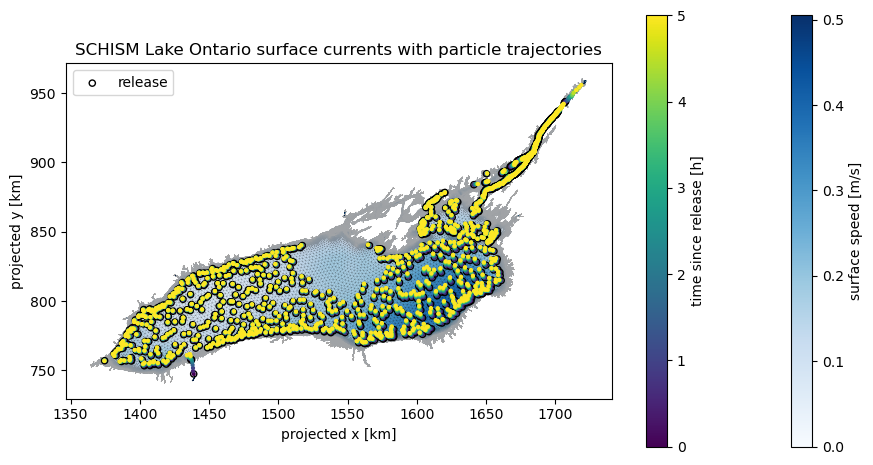

In [8]:
df = parcels.read_particlefile("output-schism.parquet")

triang = mtri.Triangulation(node_x / 1e3, node_y / 1e3, triangles=face_nodes)
surf_speed = np.hypot(
    np.asarray(uxds["U"].isel(time=0, zf=0)), np.asarray(uxds["V"].isel(time=0, zf=0))
)
speed_face = np.nanmean(surf_speed[face_nodes], axis=1)

fig, ax = plt.subplots(figsize=(11, 7))
tpc = ax.tripcolor(
    triang,
    facecolors=np.nan_to_num(speed_face),
    shading="flat",
    cmap="Blues",
    vmax=np.nanpercentile(speed_face, 98),
)
ax.triplot(triang, color="k", lw=0.2, alpha=0.35)
fig.colorbar(tpc, ax=ax, label="surface speed [m/s]", shrink=0.8)

for traj in df.sort("time").partition_by("particle_id"):
    ax.plot(
        np.array(traj["lon"]) / 1e3,
        np.array(traj["lat"]) / 1e3,
        color="0.3",
        lw=0.6,
        alpha=0.7,
        zorder=2,
    )
ax.scatter(
    lon / 1e3,
    lat / 1e3,
    facecolors="none",
    edgecolors="k",
    s=20,
    zorder=3,
    label="release",
)

elapsed_h = (df["time"] - df["time"].min()).dt.total_seconds() / 3600
sc = ax.scatter(
    np.array(df["lon"]) / 1e3,
    np.array(df["lat"]) / 1e3,
    c=elapsed_h,
    s=4,
    cmap="viridis",
    zorder=3,
)
fig.colorbar(sc, ax=ax, label="time since release [h]", shrink=0.8)

ax.set_xlabel("projected x [km]")
ax.set_ylabel("projected y [km]")
ax.set_title("SCHISM Lake Ontario surface currents with particle trajectories")
ax.set_aspect("equal")
ax.legend(loc="upper left")
plt.show()

The particles move with the SCHISM surface currents, and any that wander over shallow water where
their release depth falls below the seabed are flagged (`out_of_bounds == 1`) and stop.

From here, the rest of Parcels works exactly as on structured grids. To go further with SCHISM data:

* Keep in mind that the vertical is approximate: because Parcels uses a single 1D vertical column,
  this tutorial is most meaningful for near-surface and horizontal transport. Faithful full-depth 3D
  transport on an LSC2 grid would require Parcels to support a laterally varying vertical coordinate.
* Add the vertical velocity as a `W` field and use `AdvectionRK4_3D` for three-dimensional transport
  (still subject to the single-column vertical approximation above).
* See the [interpolation tutorial](./tutorial_interpolation.ipynb) for the available `Ux*` interpolators.